In [6]:
import pandas as pd
gsl_monthly_df = pd.read_csv('gsl_monthly_df.csv')
gsl_monthly_df.head()

,date,year,month,elevation_ft,monthly_precip_in,snow_water_equiv_in,volume_acft,SA_ac,SA_prior_month_ac,prior_month_vol_acft,precip_acft,total_inflow_cfs_acft,evaporation_acft,bear_river_acft,weber_river_acft,jordan_river_surplus_acft,jordan_river_1700_acft
0,1950-02-01,1950,2,4197.40,1.19,NaN,13231625.08,879251.73,864498.36,13013628.81,85729.420700,330234.8985,197968.049200,144101.275,36621.3605,11994.2245,7142.5835
1,1950-03-01,1950,3,4197.90,0.98,NaN,13677742.99,905185.46,879251.73,13231625.08,71805.557950,378388.3280,4075.975950,161080.035,60738.7370,11591.5740,7025.5570
2,1950-04-01,1950,4,4198.15,1.29,NaN,13905660.50,918138.01,905185.46,13677742.99,97307.436950,607916.9645,477306.891450,228618.210,144858.9720,11311.9005,7144.5670
3,1950-05-01,1950,5,4198.35,2.18,NaN,14090506.69,928507.42,918138.01,13905660.50,166795.071817,811463.7345,793412.616317,288876.940,230403.3600,14786.9925,7263.5770
4,1950-06-01,1950,6,4198.80,0.16,NaN,14513327.20,951733.99,928507.42,14090506.69,12380.098933,571448.3335,161007.922433,220446.190,123647.4230,15227.3295,7688.0460


In [7]:
# creating new dataframe with selected features for the non-snowpack model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

gsl_monthly_df = pd.read_csv('gsl_monthly_df.csv')

gsl_monthly_df['date'] = pd.to_datetime(gsl_monthly_df['date'])
gsl_monthly_df = gsl_monthly_df.sort_values('date').reset_index(drop=True)

# selecting desired features (excluding snowpack)
features = [
    'elevation_ft',
    'total_inflow_cfs_acft',
    'precip_acft',
    'evaporation_acft'
]

# making sure there are no missing values in the selected features
print(gsl_monthly_df[features].isna().sum())

gsl_monthly_nosnow = gsl_monthly_df[['date', 'year', 'month'] + features]

# filtering for complete years (12 months of data)
month_counts = gsl_monthly_nosnow.groupby('year')['month'].count()
complete_years = month_counts[month_counts == 12].index
gsl_monthly_nosnow = gsl_monthly_nosnow[gsl_monthly_nosnow['year'].isin(complete_years)].reset_index(drop=True)

# assessing complete years available
print(f"Complete years available: {len(complete_years)}")
print(f"First year: {complete_years.min()}, Last year: {complete_years.max()}")

# sorting by year and month so rows are always jan to dec for each year
gsl_monthly_nosnow = gsl_monthly_nosnow.sort_values(['year', 'month'])
gsl_monthly_nosnow.tail(20)


elevation_ft             0
total_inflow_cfs_acft    0
precip_acft              0
evaporation_acft         0
dtype: int64
Complete years available: 74
First year: 1951, Last year: 2024


,date,year,month,elevation_ft,total_inflow_cfs_acft,precip_acft,evaporation_acft
868,2023-05-01,2023,5,4193.15,1.076516e+06,28152.194633,362132.445253
869,2023-06-01,2023,6,4193.84,4.515186e+05,22014.037825,-1014.987625
870,2023-07-01,2023,7,4193.51,7.518358e+04,3499.560300,307335.956050
871,2023-08-01,2023,8,4192.88,9.369300e+04,157634.267083,679201.899783
872,2023-09-01,2023,9,4192.34,1.078542e+05,50871.873325,516986.674275
873,2023-10-01,2023,10,4192.19,9.498406e+04,107636.928950,300657.081800
874,2023-11-01,2023,11,4192.20,1.044089e+05,94603.402700,192321.254150
875,2023-12-01,2023,12,4192.43,1.154262e+05,51122.391933,15880.384133
876,2024-01-01,2024,1,4192.65,9.626739e+04,70169.508267,21206.135617
877,2024-02-01,2024,2,4193.31,1.735795e+05,186725.886750,-84205.976300


In [8]:
# building yearly matrices for each year with shape (12, 4) for the 4 features per month
# empty dictionary - keys are years, values are the 12x4 matrices
yearly_matrices_nosnow = {}
for year, group in gsl_monthly_nosnow.groupby('year'):
    matrix = group[features].values
    yearly_matrices_nosnow[year] = matrix

years = sorted(yearly_matrices_nosnow.keys())
print(f"Built {len(years)} yearly matrices")
print(f"Each matrix shape: {yearly_matrices_nosnow[years[0]].shape}")

# looking at first years matrix
print(years[0], yearly_matrices_nosnow[years[0]])

Built 74 yearly matrices
Each matrix shape: (12, 4)
1951 [[   4198.3         368931.          127480.28561667  130280.36561667]
 [   4198.5         423110.3025       49383.80906667  286081.48156667]
 [   4198.95        446585.025        98320.10895     118181.31395   ]
 [   4199.2         611598.3405      207802.47366667  578199.40416667]
 [   4199.45        688681.1175       70359.3157      515034.0032    ]
 [   4199.9         264801.217         7361.60085    -173816.26215   ]
 [   4199.55        131581.423       181218.80670833  660787.28970833]
 [   4199.15        202126.584       147084.725125    739962.419125  ]
 [   4198.85        187141.2415           0.          475346.3515    ]
 [   4198.45        271622.4735      151093.2345      800254.388     ]
 [   4198.35        271747.434       123721.92535     488677.98935   ]
 [   4198.55        310157.9115      224389.29316667  348069.18466667]]


In [9]:
# now to scale features so that no feature dominates due to scale differences
# fitting the scaler on all monthly data together so that the same scaling is applied to each year
all_monthly = gsl_monthly_nosnow[features].values
scaler = StandardScaler()
scaler.fit(all_monthly)

# applying the scaler to each year's matrix and flattening to a 48 element vector
yearly_vectors_nosnow = {}
for year in years:
    # apply the scaler we fit above to this year's 12x4 matrix
    scaled_matrix = scaler.transform(yearly_matrices_nosnow[year])
    # flatten from (12,4) to (48,) - laying all rows end to end
    yearly_vectors_nosnow[year] = scaled_matrix.flatten()

# checking out the vectors
yearly_vectors_nosnow


{1951: array([ 0.08100321,  0.73439789,  0.40015897, -0.75266707,  0.12603316,
         1.0015436 , -0.57498001, -0.13527062,  0.22735056,  1.11729207,
         0.03605516, -0.80061224,  0.28363801,  1.93093488,  1.40308894,
         1.02231139,  0.33992545,  2.31101237, -0.31307275,  0.77200449,
         0.44124285,  0.22095781, -1.09968349, -1.95771735,  0.36244043,
        -0.43591843,  1.0711563 ,  1.34958419,  0.27238052, -0.08807643,
         0.64494663,  1.66333319,  0.20483559, -0.16196571, -1.19160293,
         0.61473337,  0.11477568,  0.25459187,  0.69499823,  1.90225347,
         0.0922607 ,  0.25520802,  0.35323082,  0.66756294,  0.13729065,
         0.44460127,  1.61019757,  0.11036939]),
 1952: array([ 0.1935781 ,  0.65044479,  0.95763443, -0.12889941,  0.28363801,
         0.56189501,  0.63056012, -0.8924971 ,  0.35118294,  0.99029639,
         2.40330217,  0.37872826,  0.47501532,  3.40139526,  0.71230445,
         0.76607068,  0.59884769,  4.00233668, -0.04725285,  0.

In [10]:
# creating alternate dataframe that includes snowpack for comparison
features = [
    'elevation_ft',
    'snow_water_equiv_in',
    'total_inflow_cfs_acft',
    'precip_acft',
    'evaporation_acft'
]

# assessing amount of null values (know snowpack is limited)
print(gsl_monthly_df[features].isna().sum())

# creating new dataframe with snowpack that drops NaN snowpack values
gsl_monthly_snowpack = gsl_monthly_df[['date', 'year', 'month'] + features].dropna(subset=features)

# filtering for complete years (12 months of data)
month_counts = gsl_monthly_snowpack.groupby('year')['month'].count()
complete_years = month_counts[month_counts == 12].index
gsl_monthly_snowpack = gsl_monthly_snowpack[gsl_monthly_snowpack['year'].isin(complete_years)].reset_index(drop=True)

# assessing complete years available
print(f"Complete years available: {len(complete_years)}")
print(f"First year: {complete_years.min()}, Last year: {complete_years.max()}")

# sorting by year and month so rows are always jan to dec for each year
gsl_monthly_snowpack = gsl_monthly_snowpack.sort_values(['year', 'month'])
gsl_monthly_snowpack.head(20)

elevation_ft               0
snow_water_equiv_in      475
total_inflow_cfs_acft      0
precip_acft                0
evaporation_acft           0
dtype: int64
Complete years available: 35
First year: 1990, Last year: 2024


,date,year,month,elevation_ft,snow_water_equiv_in,total_inflow_cfs_acft,precip_acft,evaporation_acft
0,1990-01-01,1990,1,4203.71,11.0,156756.0050,58250.217575,203021.652575
1,1990-02-01,1990,2,4203.75,19.2,116758.7275,35819.900375,103378.427875
2,1990-03-01,1990,3,4203.95,25.4,157158.6555,222337.530917,132459.976417
3,1990-04-01,1990,4,4203.89,32.7,119503.8915,117770.730500,311587.182000
4,1990-05-01,1990,5,4203.72,34.0,57426.2920,169905.107625,436660.489625
5,1990-06-01,1990,6,4203.46,11.1,61760.2395,67565.133350,447275.112850
6,1990-07-01,1990,7,4202.98,0.0,36296.0665,64862.991467,680597.577967
7,1990-08-01,1990,8,4202.45,0.0,33566.7705,45878.284383,704642.154883
8,1990-09-01,1990,9,4202.03,0.0,37051.7800,54304.923867,575906.693867
9,1990-10-01,1990,10,4201.68,0.0,70582.8475,65563.379675,532058.367175


In [11]:
# building yearly matrices for each year with shape (12, 5) for the 5 features per month
# empty dictionary - keys are years, values are the 12x5 matrices
yearly_matrices_snowpack = {}
for year, group in gsl_monthly_snowpack.groupby('year'):
    matrix = group[features].values
    yearly_matrices_snowpack[year] = matrix

years = sorted(yearly_matrices_snowpack.keys())
print(f"Built {len(years)} yearly matrices")
print(f"Each matrix shape: {yearly_matrices_snowpack[years[0]].shape}")

# looking at first years matrix
print(years[0], yearly_matrices_snowpack[years[0]])

Built 35 yearly matrices
Each matrix shape: (12, 5)
1990 [[4.20371000e+03 1.10000000e+01 1.56756005e+05 5.82502176e+04
  2.03021653e+05]
 [4.20375000e+03 1.92000000e+01 1.16758727e+05 3.58199004e+04
  1.03378428e+05]
 [4.20395000e+03 2.54000000e+01 1.57158656e+05 2.22337531e+05
  1.32459976e+05]
 [4.20389000e+03 3.27000000e+01 1.19503891e+05 1.17770730e+05
  3.11587182e+05]
 [4.20372000e+03 3.40000000e+01 5.74262920e+04 1.69905108e+05
  4.36660490e+05]
 [4.20346000e+03 1.11000000e+01 6.17602395e+04 6.75651334e+04
  4.47275113e+05]
 [4.20298000e+03 0.00000000e+00 3.62960665e+04 6.48629915e+04
  6.80597578e+05]
 [4.20245000e+03 0.00000000e+00 3.35667705e+04 4.58782844e+04
  7.04642155e+05]
 [4.20203000e+03 0.00000000e+00 3.70517800e+04 5.43049239e+04
  5.75906694e+05]
 [4.20168000e+03 0.00000000e+00 7.05828475e+04 6.55633797e+04
  5.32058367e+05]
 [4.20156000e+03 0.00000000e+00 1.13073385e+05 1.16231738e+05
  3.64088732e+05]
 [4.20161000e+03 5.50000000e+00 9.80384545e+04 5.22316545e+04
 

In [12]:
# now to scale features so that no feature dominates due to scale differences
# fitting the scaler on all monthly data together so that the same scaling is applied to each year
all_monthly = gsl_monthly_snowpack[features].values
scaler = StandardScaler()
scaler.fit(all_monthly)

# applying the scaler to each year's matrix and flattening to a 48 element vector
yearly_vectors_snowpack = {}
for year in years:
    # apply the scaler we fit above to this year's 12x5 matrix
    scaled_matrix = scaler.transform(yearly_matrices_snowpack[year])
    # flatten from (12,5) to (60,) - laying all rows end to end
    yearly_vectors_snowpack[year] = scaled_matrix.flatten()

# checking out the vectors
yearly_vectors_snowpack

{1990: array([ 1.96723308, -0.21512683, -0.17770796, -0.38758384, -0.43497013,
         1.97857093,  0.24900698, -0.39828445, -0.71032869, -0.88631349,
         2.03526022,  0.59993741, -0.17548743,  1.97343204, -0.75458588,
         2.01825344,  1.0131297 , -0.38314545,  0.46884359,  0.05678765,
         1.97006754,  1.08671189, -0.72549023,  1.21899355,  0.62331896,
         1.89637146, -0.20946666, -0.70158943, -0.25355359,  0.67139889,
         1.76031717, -0.83774534, -0.84201894, -0.29243411,  1.72825494,
         1.61009055, -0.83774534, -0.85707043, -0.56560084,  1.83716712,
         1.49104304, -0.83774534, -0.83785134, -0.4443518 ,  1.25404774,
         1.39183679, -0.83774534, -0.65293462, -0.28235638,  1.05543262,
         1.35782321, -0.83774534, -0.41860833,  0.44669937,  0.29459836,
         1.37199554, -0.52643608, -0.50152278, -0.47418361, -0.92666795]),
 1991: array([ 1.38900232, -0.28304885, -0.46320493, -1.22573328, -1.18455524,
         1.41734697,  0.06788159, -0.

In [13]:
# save as numpy files (good option for dictionaries of arrays)
np.save('yearly_vectors_nosnow.npy', yearly_vectors_nosnow)
np.save('yearly_vectors_snowpack.npy', yearly_vectors_snowpack)

# code to load them back later:
yearly_vectors_nosnow = np.load('yearly_vectors_nosnow.npy', allow_pickle=True).item()
yearly_vectors_snowpack = np.load('yearly_vectors_snowpack.npy', allow_pickle=True).item()

In [24]:
from sklearn.neighbors import NearestNeighbors

years = list(yearly_vectors_nosnow.keys())    
X = np.array(list(yearly_vectors_nosnow.values()))

nbrs = NearestNeighbors(n_neighbors=5, metric='euclidean')
nbrs.fit(X)

distances, indices = nbrs.kneighbors(X)  # query all rows at once

for i, year in enumerate(years):
    neighbor_years = [years[j] for j in indices[i][1:]]  # skip self at index 0
    print(f"{year}: nearest neighbors → {neighbor_years}")

1951: nearest neighbors → [1972, 1974, 1952, 1996]
1952: nearest neighbors → [1976, 1980, 1975, 1996]
1953: nearest neighbors → [1996, 1955, 2012, 1956]
1954: nearest neighbors → [1955, 1979, 1992, 2012]
1955: nearest neighbors → [2012, 2008, 1970, 1979]
1956: nearest neighbors → [1955, 2012, 2008, 2013]
1957: nearest neighbors → [2005, 1995, 2010, 2019]
1958: nearest neighbors → [1966, 1960, 1955, 2008]
1959: nearest neighbors → [2014, 2013, 2008, 1960]
1960: nearest neighbors → [1961, 2008, 1966, 1959]
1961: nearest neighbors → [1960, 2021, 1963, 2014]
1962: nearest neighbors → [1963, 1961, 2015, 2016]
1963: nearest neighbors → [1961, 1960, 1962, 2022]
1964: nearest neighbors → [1967, 2009, 2010, 2016]
1965: nearest neighbors → [1967, 2014, 2009, 1970]
1966: nearest neighbors → [2018, 2008, 2020, 2013]
1967: nearest neighbors → [2009, 1964, 1965, 1970]
1968: nearest neighbors → [2010, 2008, 2014, 1959]
1969: nearest neighbors → [1955, 1966, 2009, 2020]
1970: nearest neighbors → [1955

In [31]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4)  # try a few values
kmeans.fit(X)

for year, label in zip(years, kmeans.labels_):
    print(f"{year}: cluster {label}")

1951: cluster 1
1952: cluster 1
1953: cluster 1
1954: cluster 0
1955: cluster 0
1956: cluster 0
1957: cluster 1
1958: cluster 0
1959: cluster 0
1960: cluster 0
1961: cluster 0
1962: cluster 0
1963: cluster 0
1964: cluster 0
1965: cluster 0
1966: cluster 0
1967: cluster 0
1968: cluster 0
1969: cluster 0
1970: cluster 0
1971: cluster 1
1972: cluster 1
1973: cluster 1
1974: cluster 1
1975: cluster 1
1976: cluster 1
1977: cluster 1
1978: cluster 1
1979: cluster 0
1980: cluster 1
1981: cluster 1
1982: cluster 1
1983: cluster 1
1984: cluster 2
1985: cluster 3
1986: cluster 2
1987: cluster 3
1988: cluster 3
1989: cluster 3
1990: cluster 1
1991: cluster 0
1992: cluster 1
1993: cluster 1
1994: cluster 1
1995: cluster 1
1996: cluster 1
1997: cluster 1
1998: cluster 1
1999: cluster 1
2000: cluster 1
2001: cluster 1
2002: cluster 0
2003: cluster 0
2004: cluster 0
2005: cluster 1
2006: cluster 1
2007: cluster 0
2008: cluster 0
2009: cluster 0
2010: cluster 0
2011: cluster 1
2012: cluster 0
2013: cl

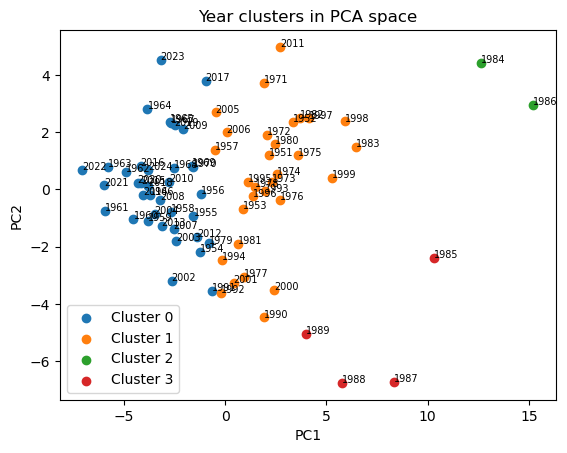

In [32]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot, coloring by cluster label
fig, ax = plt.subplots()

for cluster_id in range(4):
    mask = kmeans.labels_ == cluster_id  # boolean mask for this cluster
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f"Cluster {cluster_id}")

# Annotate each point with its year
for i, year in enumerate(years):
    ax.annotate(str(year), (X_pca[i, 0], X_pca[i, 1]), fontsize=7)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Year clusters in PCA space")
ax.legend()
plt.show()

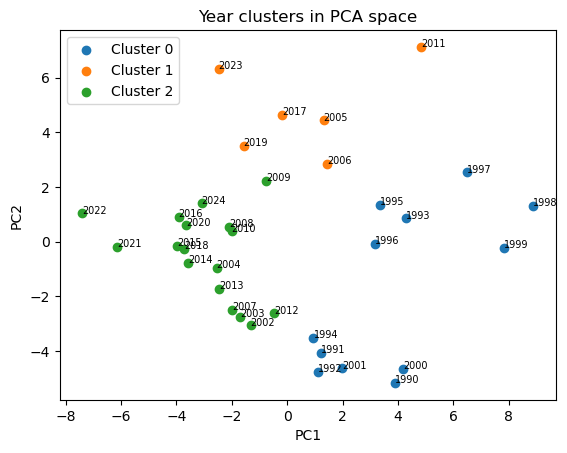

In [39]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

years = list(yearly_vectors_snowpack.keys())    
X = np.array(list(yearly_vectors_snowpack.values()))

nbrs = NearestNeighbors(n_neighbors=10, metric='euclidean')
nbrs.fit(X)

distances, indices = nbrs.kneighbors(X)  # query all rows at once

for i, year in enumerate(years):
    neighbor_years = [years[j] for j in indices[i][1:]]  # skip self at index 0
    # print(f"{year}: nearest neighbors → {neighbor_years}")

kmeans = KMeans(n_clusters=3)  # try a few values
kmeans.fit(X)

for year, label in zip(years, kmeans.labels_):
    # print(f"{year}: cluster {label}")
    pass

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot, coloring by cluster label
fig, ax = plt.subplots()

for cluster_id in range(3):
    mask = kmeans.labels_ == cluster_id  # boolean mask for this cluster
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f"Cluster {cluster_id}")

# Annotate each point with its year
for i, year in enumerate(years):
    ax.annotate(str(year), (X_pca[i, 0], X_pca[i, 1]), fontsize=7)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Year clusters in PCA space")
ax.legend()
plt.show()